In [1]:
# Preparacion del notebook

import sys
sys.path.append("..")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data import cargar_enemdu, mediana_ponderada
from src.features import agregar_variables

df = agregar_variables(cargar_enemdu())
os.makedirs("../reports/figures", exist_ok=True)

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
FUENTE = "Fuente: INEC, ENEMDU I Trimestre 2026. Cálculos propios, ponderados con fexp."

In [2]:
# Comprobacion de la funcion

ing = df[df["condact"].between(1, 6) & (df["ingrl"] > 0)]
print(ing.groupby("sexo").apply(lambda s: mediana_ponderada(s["ingrl"], s["fexp"])))

sexo
Hombre    430.0
Mujer     350.0
dtype: float64


condact
Empleo adecuado                   35.7
Subempleo                         18.4
Otro empleo no pleno              32.6
No remunerado / no clasificado     9.9
Desempleo                          3.4
Name: fexp, dtype: float64


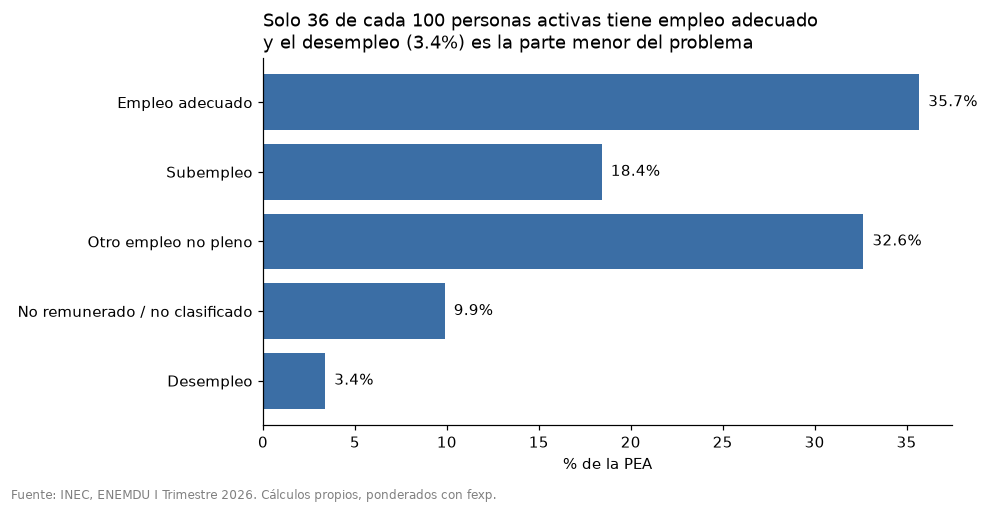

In [3]:
# Grafico 1: de que esta hecha la PEA

mapa = {1: "Empleo adecuado", 2: "Subempleo", 3: "Subempleo",
        4: "Otro empleo no pleno",
        5: "No remunerado / no clasificado", 6: "No remunerado / no clasificado",
        7: "Desempleo", 8: "Desempleo"}
orden = ["Empleo adecuado", "Subempleo", "Otro empleo no pleno",
         "No remunerado / no clasificado", "Desempleo"]

pea = df[df["condact"].between(1, 8)]
comp = pea.groupby(pea["condact"].map(mapa))["fexp"].sum()
comp = (100 * comp / comp.sum()).reindex(orden)
print(comp.round(1))

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(comp.index[::-1], comp.values[::-1], color="#3b6ea5")
for y, v in enumerate(comp.values[::-1]):
    ax.text(v + 0.5, y, f"{v:.1f}%", va="center")
ax.set_xlabel("% de la PEA")
ax.set_title(f"Solo {comp['Empleo adecuado']:.0f} de cada 100 personas activas tiene empleo adecuado\n"
             f"y el desempleo ({comp['Desempleo']:.1f}%) es la parte menor del problema", loc="left")
fig.text(0.01, -0.02, FUENTE, fontsize=8, color="gray")
fig.tight_layout()
fig.savefig("../reports/figures/01_composicion_pea.png", dpi=150, bbox_inches="tight")

Informalidad nacional: 53.5
sexo    Hombre  Mujer
zona                 
Urbana    44.7   37.2
Rural     73.5   78.9


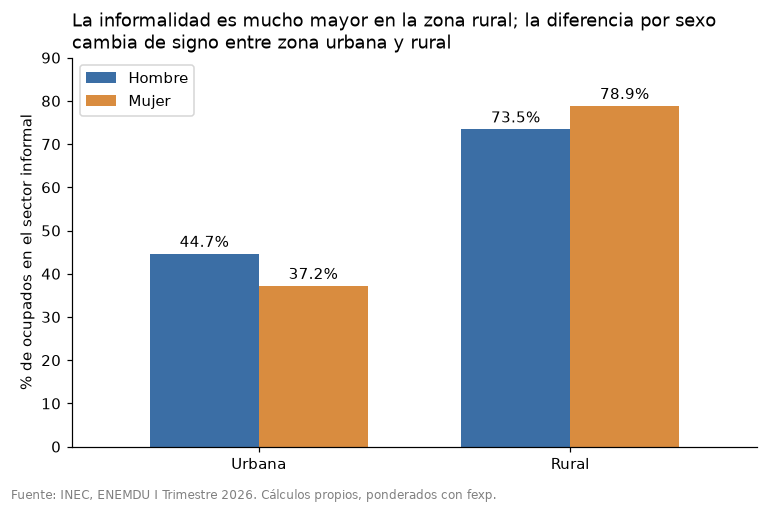

In [4]:
# Informalidad por zona y sexo

oc = df[df["informal"].notna()].copy()
oc["w_inf"] = oc["informal"] * oc["fexp"]

print("Informalidad nacional:", round(100 * oc["w_inf"].sum() / oc["fexp"].sum(), 1))   # debe dar 53.5

g = oc.groupby(["zona", "sexo"])[["w_inf", "fexp"]].sum()
res = (100 * g["w_inf"] / g["fexp"]).unstack().reindex(["Urbana", "Rural"])
print(res.round(1))

ax = res.plot(kind="bar", figsize=(7, 4.5), color=["#3b6ea5", "#d98c3f"], rot=0, width=0.7)
for c in ax.containers:
    ax.bar_label(c, fmt="%.1f%%", padding=2)
ax.set_ylabel("% de ocupados en el sector informal")
ax.set_xlabel("")
ax.set_ylim(0, 90)
ax.set_title("La informalidad es mucho mayor en la zona rural; la diferencia por sexo\n"
             "cambia de signo entre zona urbana y rural", loc="left")
ax.legend(title="")
plt.gcf().text(0.01, -0.02, FUENTE, fontsize=8, color="gray")
plt.tight_layout()
plt.savefig("../reports/figures/02_informalidad_zona_sexo.png", dpi=150, bbox_inches="tight")

sexo
Hombre    430.0
Mujer     350.0
dtype: float64 
razón: 0.814


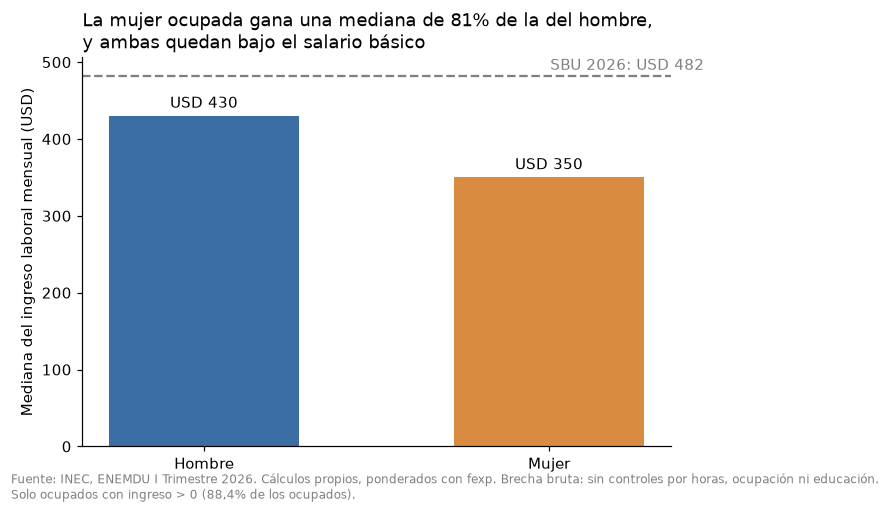

In [5]:
# Brecha de ingresos por sexo

SBU = 482
ing = df[df["condact"].between(1, 6) & (df["ingrl"] > 0)]
med = ing.groupby("sexo").apply(lambda s: mediana_ponderada(s["ingrl"], s["fexp"]))
ratio = med["Mujer"] / med["Hombre"]
print(med, f"\nrazón: {ratio:.3f}")

fig, ax = plt.subplots(figsize=(6.5, 4.5))
barras = ax.bar(med.index, med.values, color=["#3b6ea5", "#d98c3f"], width=0.55)
ax.bar_label(barras, fmt="USD %.0f", padding=3)
ax.axhline(SBU, color="gray", linestyle="--")
ax.text(1.45, SBU + 8, f"SBU 2026: USD {SBU}", ha="right", color="gray")
ax.set_ylabel("Mediana del ingreso laboral mensual (USD)")
ax.set_title(f"La mujer ocupada gana una mediana de {ratio:.0%} de la del hombre,\n"
             "y ambas quedan bajo el salario básico", loc="left")
fig.text(0.01, -0.02, FUENTE + " Brecha bruta: sin controles por horas, ocupación ni educación.\n"
         "Solo ocupados con ingreso > 0 (88,4% de los ocupados).", fontsize=8, color="gray")
fig.tight_layout()
fig.savefig("../reports/figures/03_brecha_ingreso_sexo.png", dpi=150, bbox_inches="tight")

       Empleo adecuado  Desempleo  n (sin ponderar)
15-24             18.9        8.5            5394.0
25-34             44.9        5.2            8946.0
35-44             43.0        2.0            8596.0
45-54             41.2        1.6            8286.0
55-64             32.8        0.9            6351.0
65+               12.9        0.7            4107.0


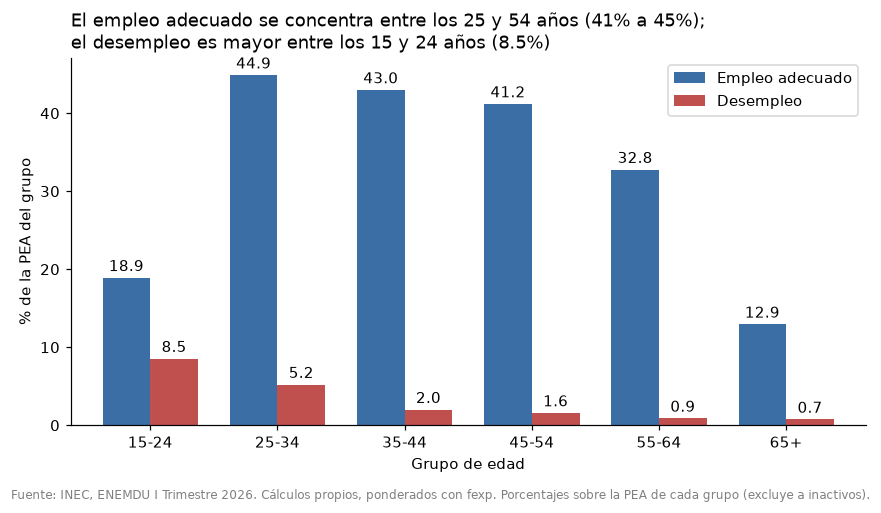

In [6]:
# Indicadores por grupo de edad

pea = df[df["condact"].between(1, 8)]

filas = {}
for g, s in pea.groupby("grupo_edad", observed=True):
    total = s["fexp"].sum()
    filas[g] = {
        "Empleo adecuado": 100 * s.loc[s["condact"] == 1, "fexp"].sum() / total,
        "Desempleo": 100 * s.loc[s["condact"].isin([7, 8]), "fexp"].sum() / total,
        "n (sin ponderar)": len(s),
    }
edad = pd.DataFrame(filas).T
print(edad.round(1))

ax = edad[["Empleo adecuado", "Desempleo"]].plot(kind="bar", figsize=(8, 4.5),
                                                  color=["#3b6ea5", "#c0504d"], rot=0, width=0.75)
for c in ax.containers:
    ax.bar_label(c, fmt="%.1f", padding=2)
ax.set_ylabel("% de la PEA del grupo")
ax.set_xlabel("Grupo de edad")
ax.set_title("El empleo adecuado se concentra entre los 25 y 54 años (41% a 45%);\n"
             f"el desempleo es mayor entre los 15 y 24 años ({edad['Desempleo'].iloc[0]:.1f}%)",
             loc="left")
plt.gcf().text(0.01, -0.02, FUENTE + " Porcentajes sobre la PEA de cada grupo (excluye a inactivos).",
               fontsize=8, color="gray")
plt.tight_layout()
plt.savefig("../reports/figures/04_indicadores_edad.png", dpi=150, bbox_inches="tight")

          % informal      n
nivel                      
Ninguno         90.0    842
Básica          74.6  12766
Media           48.3  14358
Superior        19.6  11909


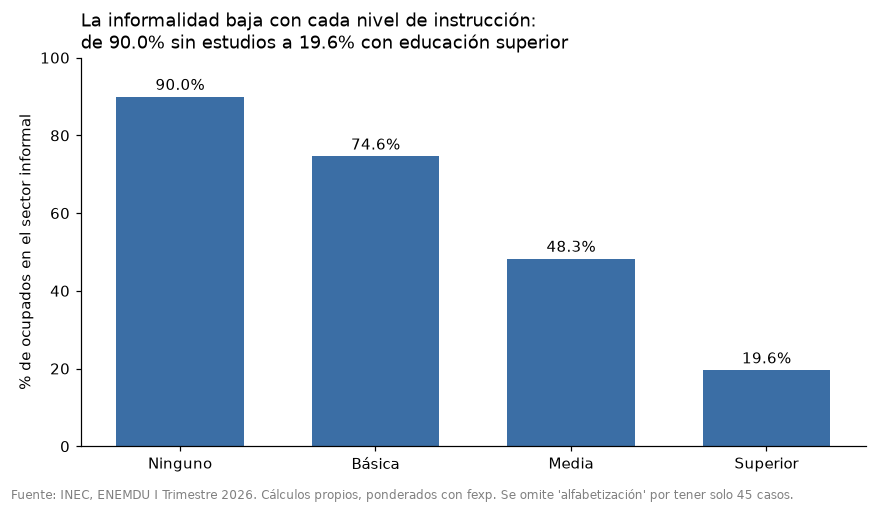

In [7]:
# Informalidad por nivel de instruccion

niveles = {1: "Ninguno", 3: "Básica", 4: "Media", 5: "Superior"}   # se omite alfabetización (n = 45)

oc = df[df["informal"].notna()].copy()
oc["nivel"] = oc["nnivins"].map(niveles)     # el código 2 queda como NaN y se excluye
oc["w_inf"] = oc["informal"] * oc["fexp"]

g = oc.groupby("nivel")[["w_inf", "fexp"]].sum()
g["% informal"] = 100 * g["w_inf"] / g["fexp"]
g["n"] = oc.groupby("nivel").size()
g = g.reindex(list(niveles.values()))
print(g[["% informal", "n"]].round(1))

fig, ax = plt.subplots(figsize=(8, 4.5))
barras = ax.bar(g.index, g["% informal"], color="#3b6ea5", width=0.65)
ax.bar_label(barras, fmt="%.1f%%", padding=2)
ax.set_ylabel("% de ocupados en el sector informal")
ax.set_ylim(0, 100)
ax.set_title("La informalidad baja con cada nivel de instrucción:\n"
             f"de {g['% informal'].iloc[0]:.1f}% sin estudios a {g['% informal'].iloc[-1]:.1f}% con educación superior",
             loc="left")
fig.text(0.01, -0.02, FUENTE + " Se omite 'alfabetización' por tener solo 45 casos.",
         fontsize=8, color="gray")
fig.tight_layout()
fig.savefig("../reports/figures/05_informalidad_instruccion.png", dpi=150, bbox_inches="tight")

          mediana      n
nivel                   
Ninguno     155.0    618
Básica      270.0  10905
Media       430.0  12699
Superior    663.0  11050


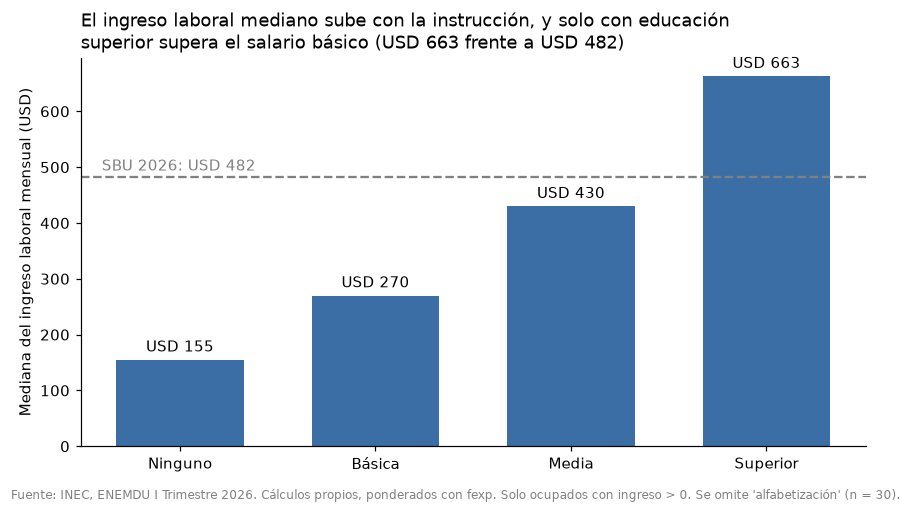

In [8]:
# Ingreso por nivel de instruccion

SBU = 482
ing = df[df["condact"].between(1, 6) & (df["ingrl"] > 0)].copy()
ing["nivel"] = ing["nnivins"].map(niveles)     # niveles definido en la celda anterior

med = ing.groupby("nivel").apply(lambda s: mediana_ponderada(s["ingrl"], s["fexp"]))
n = ing.groupby("nivel").size()
tabla = pd.DataFrame({"mediana": med, "n": n}).reindex(list(niveles.values()))
print(tabla.round(0))

fig, ax = plt.subplots(figsize=(8, 4.5))
barras = ax.bar(tabla.index, tabla["mediana"], color="#3b6ea5", width=0.65)
ax.bar_label(barras, fmt="USD %.0f", padding=3)
ax.axhline(SBU, color="gray", linestyle="--")
ax.text(-0.4, SBU + 12, f"SBU 2026: USD {SBU}", ha="left", color="gray")
ax.set_ylabel("Mediana del ingreso laboral mensual (USD)")
ax.set_title("El ingreso laboral mediano sube con la instrucción, y solo con educación\n"
             f"superior supera el salario básico (USD {tabla['mediana'].iloc[-1]:.0f} frente a USD {SBU})",
             loc="left")
fig.text(0.01, -0.02, FUENTE + " Solo ocupados con ingreso > 0. Se omite 'alfabetización' (n = 30).",
         fontsize=8, color="gray")
fig.tight_layout()
fig.savefig("../reports/figures/06_ingreso_instruccion.png", dpi=150, bbox_inches="tight")

In [9]:
# Comprobacion hipotesis: a edades altas hay mas trabajo independiente y agricola

mapa = {1: "Adecuado", 2: "Subempleo", 3: "Subempleo", 4: "Otro no pleno",
        5: "No remun./no clasif.", 6: "No remun./no clasif.", 7: "Desempleo", 8: "Desempleo"}
tab = pea.groupby(["grupo_edad", pea["condact"].map(mapa)], observed=True)["fexp"].sum().unstack()
print((100 * tab.div(tab.sum(axis=1), axis=0)).round(1))

condact     Adecuado  Desempleo  No remun./no clasif.  Otro no pleno  \
grupo_edad                                                             
15-24           18.9        8.5                  24.7           25.0   
25-34           44.9        5.2                   5.0           26.6   
35-44           43.0        2.0                   8.6           27.5   
45-54           41.2        1.6                   6.5           32.6   
55-64           32.8        0.9                   6.8           41.1   
65+             12.9        0.7                  11.4           65.8   

condact     Subempleo  
grupo_edad             
15-24            22.8  
25-34            18.4  
35-44            18.9  
45-54            18.1  
55-64            18.5  
65+               9.1  
